# **Zadanie: przestępczość**

Import nieszbednych bibliotek

In [2]:
import pandas as pd
import gspread
from gspread_dataframe import set_with_dataframe
import missingno as msno
import numpy as np

**AD 1**  
wczytanie danych z pliku csv

<Axes: >

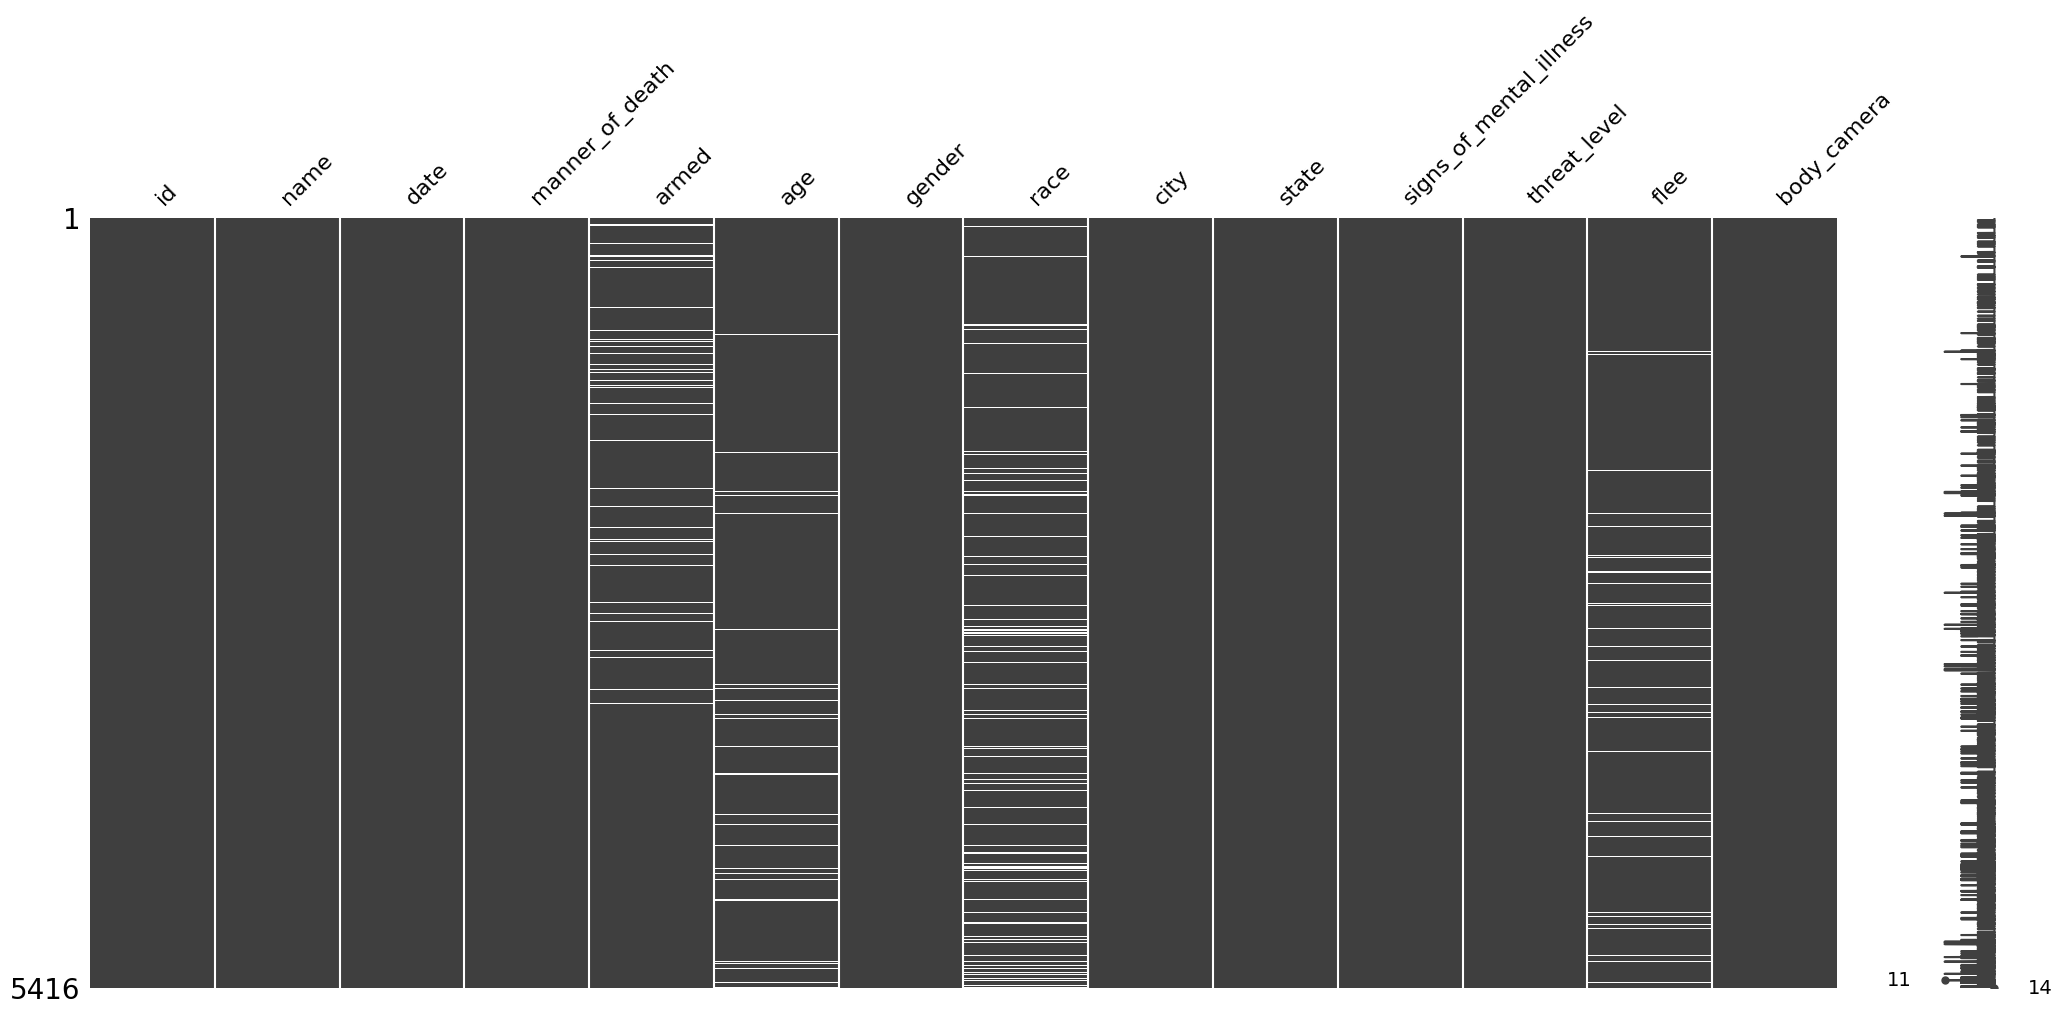

In [24]:
df = pd.read_csv('fatal-police-shootings-data.csv')
msno.matrix(df)

Wykres przedstawia brakujace dane w tabeli. Jako że kolumna 'race' będzie kluczowa w późnijszych obliczeniach braki zostaną zastąpione 'Unknown'

In [25]:
df['race'] = df['race'].fillna('Unknown')


**AD 2**  
zestawienie jednocześnie liczby ofiar interwencji według rasy (‘race’) oraz tego, czy wykazywały one oznaki choroby psychicznej (‘signs_of_mental_illness’).

In [ ]:
new_df = df.pivot_table(index='race', columns='signs_of_mental_illness', aggfunc='size', fill_value=0)
new_df = new_df.reindex(columns=[True, False], fill_value=0)

signs_of_mental_illness,True,False
race,,
A,24,69
B,184,1114
H,157,745
N,14,64
O,11,37
Unknown,113,408
W,713,1763


**AD 3**  
dodaj do tego zestawienia kolumnę wskazującą jaki odsetek ofiar interwencji wykazywało oznaki choroby psychicznej dla każdej z ras.

In [6]:
new_df['%_mental_illness'] = new_df.apply(lambda x: ((x[True] / (x[True] + x[False]))*100), axis=1)

wyświetlam odpowiedz na pytanie która z ras charakteryzuje się największym odsetkiem znamion choroby psychicznej podczas interwencji.

In [19]:
print(f"Najczęściej znamiona choroby psychicznej występują w rasie: {new_df['%_mental_illness'].idxmax()} i wynoszą {new_df['%_mental_illness'].max().round(2)}%")

Najczęściej znamiona choroby psychicznej występują w rasie: W i wynoszą 28.8%


**AD 4**  
Zamieniam wartości w kolumnie date na typ date, co umozliwia dodanie kolumny oznaczającej dzień tygodnia, w którym doszło do interwencji.

In [8]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_intervention'] = df['date'].dt.day_name()

Zliczamy interwencje według odpowiedniego dnia tygodnia, oraz ustalamy prawidłową kolejnosc dni tygodnia

In [9]:
days_count = df['day_of_intervention'].value_counts()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days_count = days_count.reindex(order)

Tworzymy wykres kolumnowy, tak aby dni tygodnia były uszeregowane od poniedziałku do niedzieli.

<Axes: title={'center': 'Liczba śmiertelnych interwencji policji w USA w zależności od dnia tygodnia'}, xlabel='Dzień tygodnia', ylabel='Liczba interwencji'>

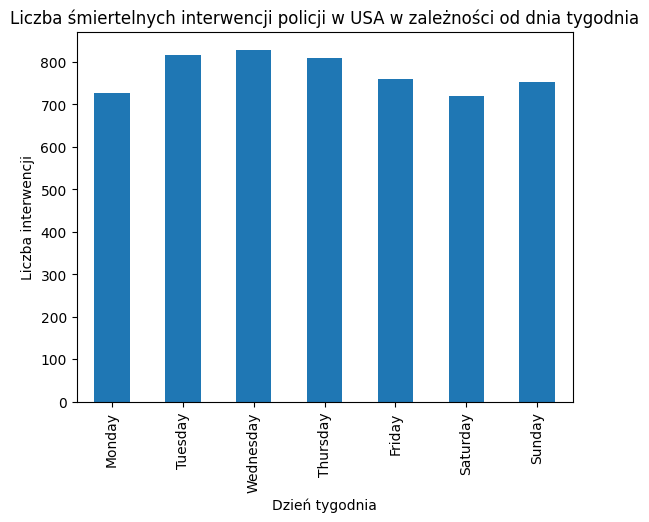

In [10]:
days_count.plot(
    kind='bar', 
    title='Liczba śmiertelnych interwencji policji w USA w zależności od dnia tygodnia',
    xlabel='Dzień tygodnia',
    ylabel='Liczba interwencji',
)


**AD 5**  
Wczytujemy do projektu dane dotyczące populacji w poszczególnych stanach USA

In [11]:


user_agent = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'}

adres_url_1 = 'https://simple.wikipedia.org/wiki/List_of_U.S._states_by_population'
data = pd.read_html(adres_url_1, header=0, storage_options=user_agent)
df_state_by_population = data[0]



Wczytujemy do projektu dane dotyczące skrótów poszczególnych stanów.

In [12]:
adres_url_2 = 'https://en.wikipedia.org/wiki/List_of_U.S._state_and_territory_abbreviations'
data = pd.read_html(adres_url_2, header=0, storage_options=user_agent)
df_territory_abbreviations = data[1]

Łączymy tabele df_territory_abbreviations oraz df_state_by_population, wycigając interesujace nas informacje. 
Usuwamy powtarzającą się kolumnę i zmieniamy nazwe kolumny

In [13]:


state_population_df = pd.merge(
    df_territory_abbreviations[['Name', 'USPS (& ANSI)']],
    df_state_by_population[['State', 'Census population, April 1, 2020 [1][2]']], 
    left_on='Name', right_on='State',                          
    how='inner'                           
)
state_population_df = state_population_df.drop(columns='Name')
state_population_df = state_population_df.rename(columns={
    'USPS (& ANSI)': 'state', 
    'Census population, April 1, 2020 [1][2]': 'population'
})

Wyciągamy z głownej tabeli interesujace nas informacje dotyczące incydentów w kazdym ze stanów

In [14]:

state_incidents_df = df.pivot_table(index='state', aggfunc='size')
state_incidents_df = state_incidents_df.to_frame(name='incidents')
state_incidents_df = state_incidents_df.reset_index() 

Ponownie łaczymy tabele w celu uzyskania interesujacych nas informacji

In [15]:
incidents_per_polulation_df = pd.merge(
    state_population_df[['state', 'State', 'population']],
    state_incidents_df[['state', 'incidents']], 
    on='state',                          
    how='inner'                           
)

Wykożystujemy utworzoną tabele by obliczyć współczynnik incydentów na 1000 mieszkańców w każdym ze stanów.

In [30]:
incidents_per_polulation_df['ratio'] = incidents_per_polulation_df.apply(lambda x: (x['incidents'] / x['population']) * 1000, axis=1)
incidents_per_polulation_df.head(10)

,state,State,population,incidents,ratio
0,AL,Alabama,5024279,104,0.020699
1,AK,Alaska,733391,39,0.053178
2,AZ,Arizona,7151502,254,0.035517
3,AR,Arkansas,3011524,83,0.027561
4,CA,California,39538223,799,0.020208
5,CO,Colorado,5773714,195,0.033774
6,CT,Connecticut,3605944,21,0.005824
7,DE,Delaware,989948,13,0.013132
8,DC,District of Columbia,689545,13,0.018853
9,FL,Florida,21538187,350,0.016250


Tabela przedstawia zestawienie wszystkich stanów w których doszło do śmiertelnych interwencji policji w USA, zestawienie zaiwera liczbe ludności, liczbę incydentów i współczynnik ilośc incydentów na 1000 mieszkanców

Wyświetlenie stanów z najmniejsyzm i najwiekszym wspólczynnikiem śmiertelnych interwencji policji na 1000 mieszkanców

In [17]:
min_row = incidents_per_polulation_df.loc[(incidents_per_polulation_df['ratio'].idxmin())]
max_row = incidents_per_polulation_df.loc[(incidents_per_polulation_df['ratio'].idxmax())]

print(f"Najmniej incydentów na 1000 mieszkańców odnotowano w stanie {min_row['State']} ({min_row['state']}). Wskaźnik wyniósł tam {min_row['ratio']:.4f}.")
print(f"Najwięcej incydentów na 1000 mieszkańców odnotowano w stanie {max_row['State']} ({max_row['state']}). Wskaźnik wyniósł tam {max_row['ratio']:.4f}.")


Najmniej incydentów na 1000 mieszkańców odnotowano w stanie Rhode Island (RI). Wskaźnik wyniósł tam 0.0036.
Najwięcej incydentów na 1000 mieszkańców odnotowano w stanie Alaska (AK). Wskaźnik wyniósł tam 0.0532.
